In [36]:
import pandas as pd
from pandas import DataFrame
import numpy as np
import networkx as nx
import peartree as pear
import partridge as ptg
import matplotlib.pyplot as plt
import itertools
import warnings
import matplotlib.colors
import json
warnings.filterwarnings('ignore')
matplotlib.style.use('default')

## Midday


In [37]:
f = open("subwaygraph_midday.json",'r')
G = nx.node_link_graph(json.load(f), directed=False, multigraph=True, edges='edges')

In [38]:
line_name = [str(s) for s in [1,2,3,4,5,6,'6X',7,'7X','A','B','C','D','E','F','G','H','J','L','M','N','Q','R','W','Z','FS','GS','Transfer']]

In [39]:
colors = ['#0062CF','#EB6800','#799534','#8E5C33','#7C858C','#F6BC26','#7C858C','#D82233','#009952','#9A38A1']
lines = [n.split(",") for n in ["A,C,E","B,D,F,M","G","J,Z","L","N,Q,R,W","FS,GS,H","1,2,3","4,5,6,6X","7,7X",]]
colorcode = pd.DataFrame([lines,colors]).T
colorcode.columns=['line', 'color']
colorcode = colorcode.explode('line').set_index('line')
cold = {k: list(v.values())[0] for k,v in colorcode.to_dict('index').items()}

In [40]:
pd.DataFrame.from_dict(dict(G.nodes.data())).T.drop('wait_time',axis=1).to_csv('nodedata.csv')

In [41]:
nodes = pd.DataFrame.from_dict(dict(G.nodes.data())).T
nodes['wait_time'] = [sorted(list(k.items())) for k in nodes['wait_time']]
nodes['lines'] = [sorted(n) for n in nodes['lines']]
nodes['same_stop'] = np.arange(len(nodes))
node_parts = nodes.copy()
nodes = nodes.explode(['lines', 'wait_time'])
nodes.reset_index(drop=True, inplace=True)
nodes.sort_values(['same_stop','lines'], inplace=True)
nodes_named = nodes.copy()
idx = zip(nodes['GTFS Stop ID'], nodes['lines'])
nodes.index = [tuple(k) for k in idx]
nodes['wait_time'] = [n[1] for n in nodes['wait_time']]
xy = pd.read_csv('gtfs_subway/stops.txt')
xy = xy[[len(k) == 3 for k in xy['stop_id']]]
xy = xy.rename({'stop_lat': 'y', 'stop_lon':'x'}, axis=1)[['stop_id','x','y']].set_index('stop_id')
xyd = xy.to_dict('index')
nodes['x'] = [xyd[n]['x'] for n in nodes['GTFS Stop ID']]
nodes['y'] = [xyd[n]['y'] for n in nodes['GTFS Stop ID']]
nodes['color'] = [cold[s] for s in nodes['lines']]

In [42]:
nodes_named.reset_index(drop=True, inplace=True)
nodes_named['key'] = [line_name.index(n) for n in nodes_named.lines]
nodes_named.index = zip(nodes_named['GTFS Stop ID'], nodes_named['key'])
nodes_named.sort_index()

,GTFS Stop ID,Complex ID,Stop Name,wait_time,lines,same_stop,key
"(101, 0)",101,293,Van Cortlandt Park-242 St,"(1, 333.875)",1,214,0
"(103, 0)",103,294,238 St,"(1, 334.966)",1,61,0
"(104, 0)",104,295,231 St,"(1, 334.966)",1,449,0
"(106, 0)",106,296,Marble Hill-225 St,"(1, 334.966)",1,326,0
"(107, 0)",107,297,215 St,"(1, 334.966)",1,247,0
...,...,...,...,...,...,...,...
"(R44, 22)",R44,38,86 St,"(R, 479.546)",R,335,22
"(R45, 22)",R45,39,Bay Ridge-95 St,"(R, 479.546)",R,409,22
"(S01, 25)",S01,627,Franklin Av,"(FS, 600.0)",FS,1,25
"(S03, 25)",S03,141,Park Pl,"(FS, 600.0)",FS,384,25


In [43]:
edges = pd.DataFrame.from_dict(G.edges(data=True, keys=True))
edges.columns = ['stop1', 'stop2', 'line', 'time']
edges['time'] = [list(v.values())[0] for v in edges['time']]
ecolor = {k: list(v.values())[0] for k,v in colorcode.to_dict('index').items()}
ecolor['Transfer'] = '#000000'
edges['color'] = [ecolor[n] for n in edges.line]	

In [44]:
edges

,stop1,stop2,line,time,color
0,127,126,1,106.0,#D82233
1,127,128,1,90.0,#D82233
2,127,128,2,60.0,#D82233
3,127,128,3,60.0,#D82233
4,127,123,2,240.0,#D82233
...,...,...,...,...,...
810,F23,R33,Transfer,180.0,#000000
811,137,228,2,75.0,#D82233
812,137,228,3,75.0,#D82233
813,239,235,4,274.0,#009952


In [45]:
node_parts

,GTFS Stop ID,Complex ID,Stop Name,wait_time,lines,same_stop
127,127,611,Times Sq-42 St,"[(1, 336.697), (2, 480.0), (3, 479.572)]","[1, 2, 3]",0
S01,S01,627,Franklin Av,"[(FS, 600.0)]",[FS],1
254,254,349,Junius St,"[(3, 480.857)]",[3],2
M01,M01,108,Middle Village-Metropolitan Av,"[(M, 480.857)]",[M],3
726,726,471,34 St-Hudson Yards,"[(7, 301.225), (7X, 540.0)]","[7, 7X]",4
...,...,...,...,...,...,...
L08,L08,120,Bedford Av,"[(L, 265.068)]",[L],470
B06,B06,222,Roosevelt Island,"[(F, 401.486)]",[F],471
J15,J15,83,Woodhaven Blvd,"[(J, 479.627)]",[J],472
F14,F14,232,2 Av,"[(F, 401.486)]",[F],473


In [46]:
edges.sort_values('line')
edge_key = edges.copy()
edge_transfer = edge_key[edge_key['line']=='Transfer']
edge_key = edge_key[edge_key['line']!='Transfer']
edge_key['stop1'] = list(zip(edge_key['stop1'], edge_key['line']))
edge_key['stop2'] = list(zip(edge_key['stop2'], edge_key['line']))
transfers = pd.concat([edge_transfer['stop1'],edge_transfer['stop2']]).unique()
node_transfer_edges = node_parts[[k in transfers for k in node_parts['GTFS Stop ID']]].reset_index()
line_dict = dict(zip(node_transfer_edges['index'], node_transfer_edges['lines']))
edge_transfer['key1'] = [line_dict[n] for n in edge_transfer['stop1']]
edge_transfer['key2'] = [line_dict[n] for n in edge_transfer['stop2']]
stop_dict = dict(zip(node_transfer_edges['index'], node_transfer_edges['same_stop']))
edge_transfer['same_stop'] = [stop_dict[n] for n in edge_transfer['stop2']]
edge_transfer = edge_transfer.explode('key1').explode('key2').reset_index(drop=True)

In [47]:
edge_transfer

,stop1,stop2,line,time,color,key1,key2,same_stop
0,127,725,Transfer,180.0,#000000,1,7,54
1,127,725,Transfer,180.0,#000000,1,7X,54
2,127,725,Transfer,180.0,#000000,2,7,54
3,127,725,Transfer,180.0,#000000,2,7X,54
4,127,725,Transfer,180.0,#000000,3,7,54
...,...,...,...,...,...,...,...,...
335,R17,D17,Transfer,180.0,#000000,W,D,461
336,R17,D17,Transfer,180.0,#000000,W,F,461
337,R17,D17,Transfer,180.0,#000000,W,M,461
338,F23,R33,Transfer,180.0,#000000,F,R,439


In [48]:
edge_transfer

,stop1,stop2,line,time,color,key1,key2,same_stop
0,127,725,Transfer,180.0,#000000,1,7,54
1,127,725,Transfer,180.0,#000000,1,7X,54
2,127,725,Transfer,180.0,#000000,2,7,54
3,127,725,Transfer,180.0,#000000,2,7X,54
4,127,725,Transfer,180.0,#000000,3,7,54
...,...,...,...,...,...,...,...,...
335,R17,D17,Transfer,180.0,#000000,W,D,461
336,R17,D17,Transfer,180.0,#000000,W,F,461
337,R17,D17,Transfer,180.0,#000000,W,M,461
338,F23,R33,Transfer,180.0,#000000,F,R,439


In [49]:
nodes

,GTFS Stop ID,Complex ID,Stop Name,wait_time,lines,same_stop,x,y,color
"(127, 1)",127,611,Times Sq-42 St,336.697,1,0,-73.987495,40.755290,#D82233
"(127, 2)",127,611,Times Sq-42 St,480.000,2,0,-73.987495,40.755290,#D82233
"(127, 3)",127,611,Times Sq-42 St,479.572,3,0,-73.987495,40.755290,#D82233
"(S01, FS)",S01,627,Franklin Av,600.000,FS,1,-73.955827,40.680596,#7C858C
"(254, 3)",254,349,Junius St,480.857,3,2,-73.902447,40.663515,#D82233
...,...,...,...,...,...,...,...,...,...
"(L08, L)",L08,120,Bedford Av,265.068,L,470,-73.956872,40.717304,#7C858C
"(B06, F)",B06,222,Roosevelt Island,401.486,F,471,-73.953260,40.759145,#EB6800
"(J15, J)",J15,83,Woodhaven Blvd,479.627,J,472,-73.851576,40.693879,#8E5C33
"(F14, F)",F14,232,2 Av,401.486,F,473,-73.989938,40.723402,#EB6800


In [50]:
gn = nx.DiGraph(name='dimensional')
gn.add_nodes_from(list(nodes.to_dict('index').items()))
gn.add_weighted_edges_from(zip(edge_key['stop1'], edge_key['stop2'], edge_key['time']), weight='travel_time', transfer=0,same_stop=0)
gn.add_weighted_edges_from(zip(edge_key['stop2'], edge_key['stop1'], edge_key['time']), weight='travel_time', transfer=0,same_stop=0)
for name, group in nodes.groupby('same_stop'):
	for u,v in list(itertools.permutations(group.index.to_list(),2)):
		gn.add_weighted_edges_from([(u,v,group['wait_time'][v])], weight='travel_time', transfer=1, same_stop=1)

In [51]:
nx.number_connected_components(nx.to_undirected(gn))

5

In [52]:
gn.number_of_edges()

2224

In [53]:
te = zip(zip(edge_transfer['stop1'], edge_transfer['key1']), zip(edge_transfer['stop2'], edge_transfer['key2']), edge_transfer['time'])
te = pd.DataFrame(te, columns=['stop1','stop2','time'])
te2 = te[['stop2','stop1','time']]
te = pd.concat([te,te2]).reset_index(drop=True)
te['transfer'] = 1
te['in_complex'] = 0
te.rename(columns={'time':'travel_time'}, inplace=True)

In [54]:
gn.add_weighted_edges_from(zip(te['stop1'], te['stop2'], te['travel_time']), weight='travel_time', transfer=1,same_stop=0)

In [55]:
dir_edges = pd.concat([pd.DataFrame.from_dict(gn.in_edges(data=True)), pd.DataFrame.from_dict(gn.out_edges(data=True))])
dir_edges.columns = ['stop1', 'stop2', 'data']
dir_edges.reset_index(drop=True, inplace=True)
dir_edges = pd.concat([dir_edges.drop('data', axis=1), pd.json_normalize(dir_edges['data'])], axis=1)

In [56]:
no_complex = pd.DataFrame.from_dict(gn.out_edges(data=True))
no_complex.columns = ['stop1', 'stop2', 'data']
no_complex

,stop1,stop2,data
0,"(127, 1)","(126, 1)","{'transfer': 0, 'same_stop': 0, 'travel_time':..."
1,"(127, 1)","(128, 1)","{'transfer': 0, 'same_stop': 0, 'travel_time':..."
2,"(127, 1)","(127, 2)","{'transfer': 1, 'same_stop': 1, 'travel_time':..."
3,"(127, 1)","(127, 3)","{'transfer': 1, 'same_stop': 1, 'travel_time':..."
4,"(127, 1)","(725, 7)","{'transfer': 1, 'same_stop': 0, 'travel_time':..."
...,...,...,...
2559,"(J15, J)","(J16, J)","{'transfer': 0, 'same_stop': 0, 'travel_time':..."
2560,"(F14, F)","(F15, F)","{'transfer': 0, 'same_stop': 0, 'travel_time':..."
2561,"(F14, F)","(D21, F)","{'transfer': 0, 'same_stop': 0, 'travel_time':..."
2562,"(253, 3)","(254, 3)","{'transfer': 0, 'same_stop': 0, 'travel_time':..."


In [57]:
nx.set_edge_attributes(gn, {(u,v): {'line': u[1] if k['transfer'] == 0 else 'Transfer'} for u,v,k in gn.edges.data()})
nx.set_edge_attributes(gn, {(u,v): {'line': u[1] if k['transfer'] == 0 else 'Transfer'} for u,v,k in gn.in_edges.data()})
gn.edges.data()

OutEdgeDataView([(('127', '1'), ('126', '1'), {'transfer': 0, 'same_stop': 0, 'travel_time': 106.0, 'line': '1'}), (('127', '1'), ('128', '1'), {'transfer': 0, 'same_stop': 0, 'travel_time': 90.0, 'line': '1'}), (('127', '1'), ('127', '2'), {'transfer': 1, 'same_stop': 1, 'travel_time': np.float64(480.0), 'line': 'Transfer'}), (('127', '1'), ('127', '3'), {'transfer': 1, 'same_stop': 1, 'travel_time': np.float64(479.572), 'line': 'Transfer'}), (('127', '1'), ('725', '7'), {'transfer': 1, 'same_stop': 0, 'travel_time': 180.0, 'line': 'Transfer'}), (('127', '1'), ('725', '7X'), {'transfer': 1, 'same_stop': 0, 'travel_time': 180.0, 'line': 'Transfer'}), (('127', '1'), ('902', 'GS'), {'transfer': 1, 'same_stop': 0, 'travel_time': 180.0, 'line': 'Transfer'}), (('127', '1'), ('A27', 'A'), {'transfer': 1, 'same_stop': 0, 'travel_time': 300.0, 'line': 'Transfer'}), (('127', '1'), ('A27', 'C'), {'transfer': 1, 'same_stop': 0, 'travel_time': 300.0, 'line': 'Transfer'}), (('127', '1'), ('A27', 'E

### visuals

In [58]:
colors = ['#0062CF','#EB6800','#799534','#8E5C33','#7C858C','#F6BC26','#7C858C','#D82233','#009952','#9A38A1']
lines = [n.split(",") for n in ["A,C,E","B,D,F,M","G","J,Z","L","N,Q,R,W","FS,GS,H","1,2,3","4,5,6,6X","7,7X",]]

In [59]:
fg = gn.subgraph(filter(lambda x: x[1] in ["GS", 'E','3', '7'],gn.nodes))
fg = gn.copy()

In [60]:
from sklearn.preprocessing import normalize

In [61]:
pos = pd.DataFrame.from_dict(dict(fg.nodes.data())).T[['x','y']].reset_index()
pos['id'] = list(zip(pos['level_0'], pos['level_1']))
pos = pos.drop(['level_0','level_1'], axis=1)[['id','x','y']]
posd = pos.set_index('id').to_dict('index')
xy = [w for w in [[l for l in n.values()] for n in [k for k in posd.values()]]]
xyn = [w for w in normalize(xy, axis=0, norm='l2')]
xyoffset = list(zip(xyn, [x[1] for x in pos['id']]))
xyo2 = [tuple(k[0]) for k in xyoffset]


In [62]:
pos

,id,x,y
0,"(127, 1)",-73.987495,40.75529
1,"(127, 2)",-73.987495,40.75529
2,"(127, 3)",-73.987495,40.75529
3,"(S01, FS)",-73.955827,40.680596
4,"(254, 3)",-73.902447,40.663515
...,...,...,...
752,"(L08, L)",-73.956872,40.717304
753,"(B06, F)",-73.95326,40.759145
754,"(J15, J)",-73.851576,40.693879
755,"(F14, F)",-73.989938,40.723402


In [63]:
xyd = pd.Series(xyo2).sort_values()
xyd=xyd.reset_index().drop('index',axis=1)
xyn2 = dict(zip(pos['id'],xyo2))

In [64]:
eclist = [ecolor[k] for u,v,k in fg.edges(data='line')]

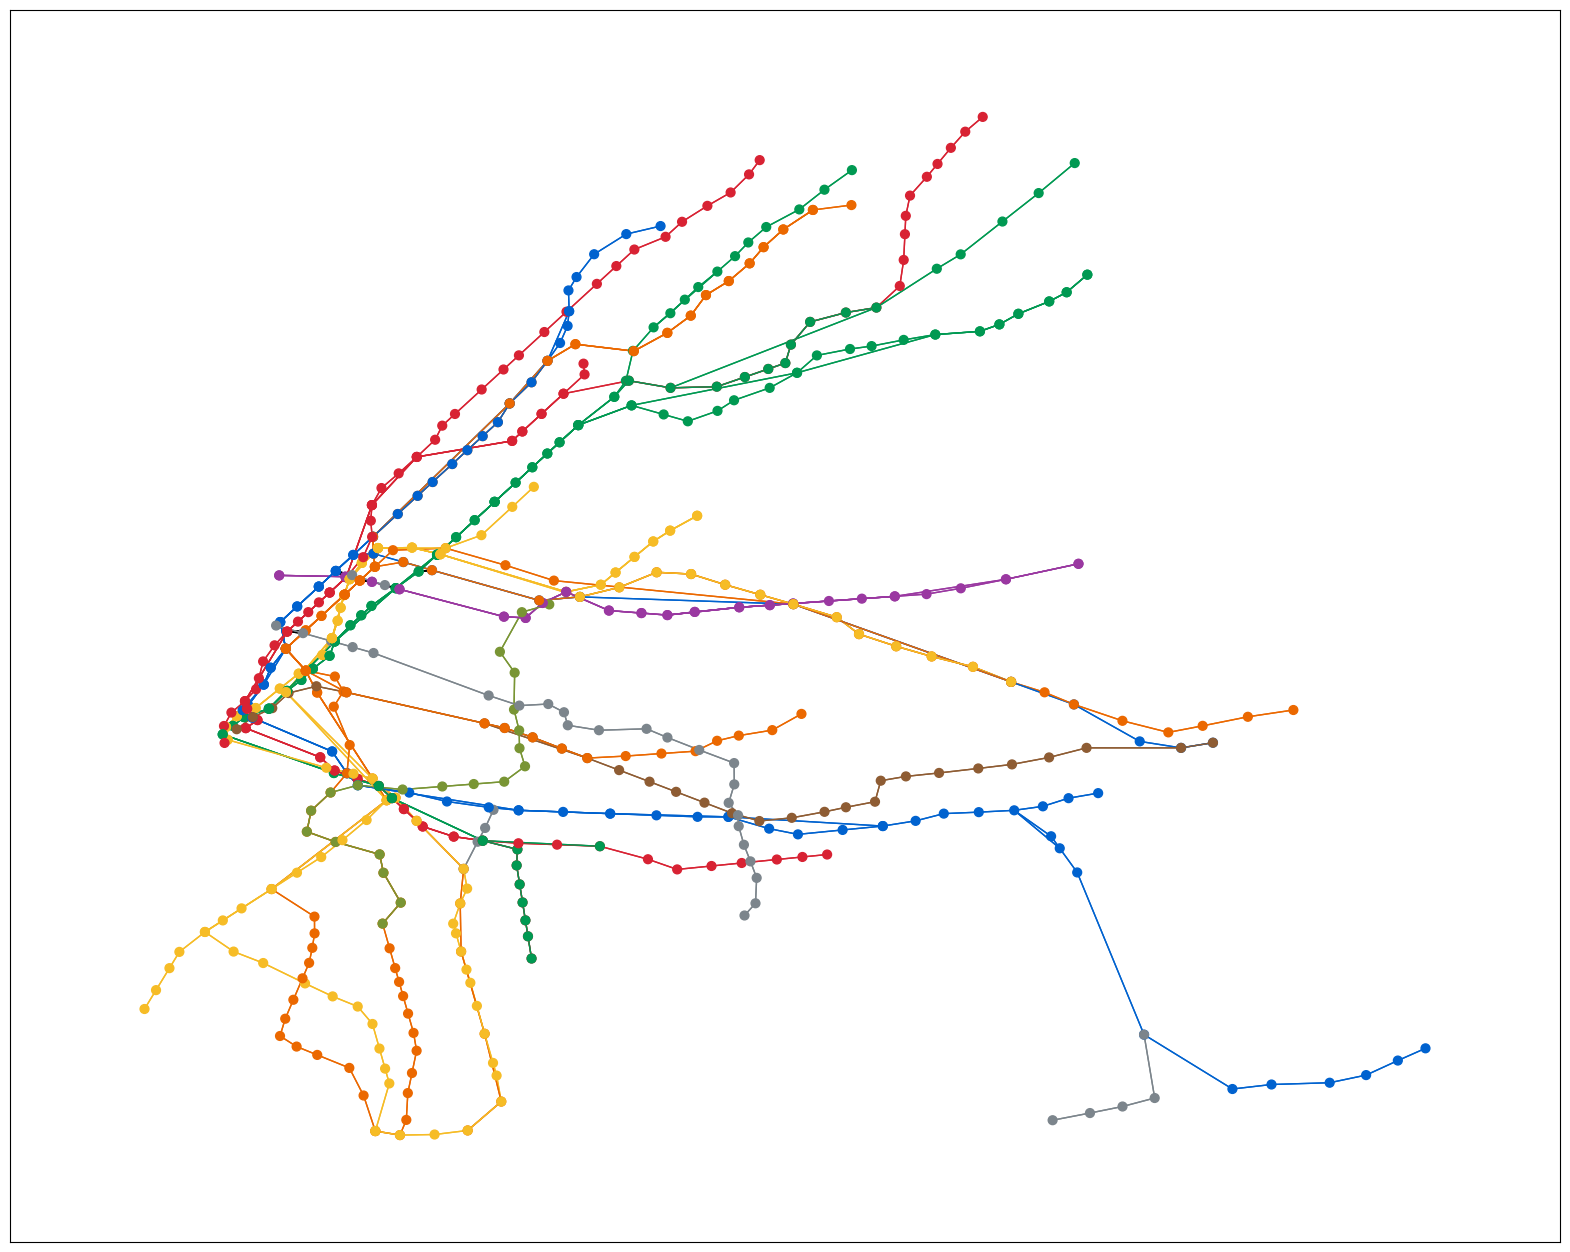

In [65]:
eclist = [ecolor[k] for u,v,k in fg.edges(data='line')]
colors = [fg.nodes[node]['color'] for node in list(fg.nodes())]

plt.figure(figsize=(20,16))
nx.draw_networkx_nodes(fg, node_color=colors, pos=xyn2, node_size=40, label=False)
nx.draw_networkx_edges(fg,pos=xyn2,arrows=False, node_size=40, edge_color=eclist)
plt.show()

In [66]:
nx.shortest_path_length(gn, ('252','3'),('612','6'))

21

In [67]:
import json

def serialize(obj):
    if isinstance(obj, np.int64):
         return int(obj)
    if not isinstance(obj, (str, int, float, bool)):
        return list(obj)
    else: return obj

gn.name = "NYC Subway Midday Directed"
try: del gn.graph['crs']
except KeyError:
	pass
data1 = nx.node_link_data(gn, edges="edges")
with open('subwaygraph_midday_dir.json', 'w') as f:
    json.dump(data1,f, default=serialize)

In [68]:
';'.join(map(str, [1,2,3]))

'1;2;3'

In [69]:
f1 = open("subwaygraph_midday_dir.json",'r')
gdd = nx.node_link_graph(json.load(f1), directed=True, multigraph=False, edges='edges')

## Rush Hour

In [70]:
G_rush = nx.MultiGraph(name="rush hour")
nodes = pd.DataFrame.from_dict(dict(G.nodes.data())).T
G_rush.add_nodes_from(G.nodes)
G_rush.nodes.data()
## Same nodes, new wait time calcs

NodeDataView({'127': {}, 'S01': {}, '254': {}, 'M01': {}, '726': {}, '713': {}, '615': {}, 'M11': {}, 'F16': {}, 'F33': {}, '233': {}, 'M05': {}, 'R43': {}, 'A36': {}, '604': {}, 'D09': {}, '629': {}, '219': {}, 'F39': {}, 'N09': {}, '610': {}, 'F32': {}, 'R13': {}, 'B22': {}, '622': {}, 'H14': {}, 'F05': {}, 'R19': {}, 'R18': {}, '114': {}, 'A03': {}, 'M16': {}, '720': {}, 'A16': {}, 'A41': {}, 'R39': {}, 'A52': {}, 'G34': {}, 'D30': {}, 'G20': {}, '418': {}, '212': {}, '503': {}, 'B18': {}, 'G29': {}, 'G21': {}, '406': {}, 'R23': {}, '110': {}, 'G09': {}, 'A51': {}, 'R01': {}, '246': {}, 'L15': {}, '725': {}, 'H01': {}, 'J22': {}, 'A20': {}, 'A57': {}, 'G15': {}, 'D34': {}, '103': {}, '238': {}, '637': {}, 'D29': {}, '705': {}, 'A15': {}, 'D18': {}, '419': {}, 'N08': {}, '115': {}, '226': {}, '136': {}, '410': {}, 'D14': {}, 'D08': {}, 'M20': {}, 'L10': {}, 'A30': {}, 'A46': {}, 'N03': {}, '504': {}, 'R06': {}, 'D03': {}, '619': {}, 'M10': {}, '242': {}, 'F22': {}, '611': {}, 'Q05': 